In [1]:
import numpy as np
import matplotlib.pyplot as plt

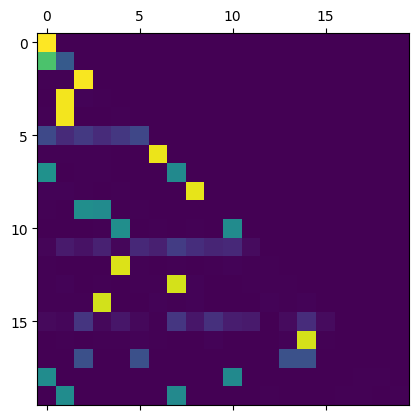

In [36]:
# start with a random square matrix, make it LT, normalize rows
n: int = 20
A: np.ndarray = np.random.rand(n, n)
# add salt and pepper noise
A[A < 0.9] = 0
A = A + np.random.rand(n, n) * 0.01
A = np.tril(A)
A = A / np.sum(A, axis=1)[:, np.newaxis]

plt.matshow(A)

In [12]:
import json
from pathlib import Path
from jaxtyping import Float


# load activations for each prompt
def load_activations(
	model_name: str,
	base_path: Path = Path("../docs/demo"),
) -> tuple[
	list[dict],
	list[np.lib.npyio.NpzFile],
]:
	model_path: Path = base_path / model_name
	with open(model_path / "prompts.jsonl") as f:
		prompts = [json.loads(line) for line in f]

	activations = [
		np.load(model_path / "prompts" / p["hash"] / "activations.npz") for p in prompts
	]

	return prompts, activations


PROMPTS, ACTIVATIONS = load_activations("pythia-14m")


def get_single_attn_pattern(
	sample: int,
	layer: int,
	head: int,
	activations=ACTIVATIONS,
) -> Float[np.ndarray, "n_ctx n_ctx"]:
	return activations[sample][f"blocks.{layer}.attn.hook_pattern"][0, head]


A = get_single_attn_pattern(0, 1, 0)
n: int = A.shape[0]

In [18]:
def transition_tensor(A: np.ndarray, K: int) -> np.ndarray:
	"""
	Compute the 3D array `X` of shape `(n, n, K+1)` such that `X[i, j, k]` = Probability of being in state j at step k if we start in state i at step 0.

	# Parameters
	- `A: np.ndarray`
	    An n x n transition matrix (row-stochastic for a standard Markov chain).
	- `K: int`
	    The maximum number of steps for which to compute transition probabilities.

	# Returns
	`X: np.ndarray`
	    A 3D NumPy array of shape (n, n, K+1).
	    - X[:, :, 0] is the identity matrix (k=0).
	    - X[:, :, k] is A^k for k >= 1.
	"""
	n: int = A.shape[0]
	# Allocate output array
	X = np.zeros((n, n, K + 1), dtype=A.dtype)

	# Step 0: identity distribution
	X[:, :, 0] = np.eye(n, dtype=A.dtype)

	# Compute powers of A iteratively
	for k in range(1, K + 1):
		X[:, :, k] = X[:, :, k - 1] @ A

	return X


def resampled_tt(
	matrix,
	exact_l10: int = 1,
	approx_l10: int = 3,
	approx_pts: int = 20,
):
	resampled_idxs = np.logspace(exact_l10, approx_l10, approx_pts, base=10, dtype=int)

	tt = transition_tensor(matrix, resampled_idxs[-1])

	tt_resampled = np.concatenate(
		[
			tt[:, :, :exact_l10],
			tt[:, :, resampled_idxs],
		],
		axis=-1,
	)

	return tt_resampled

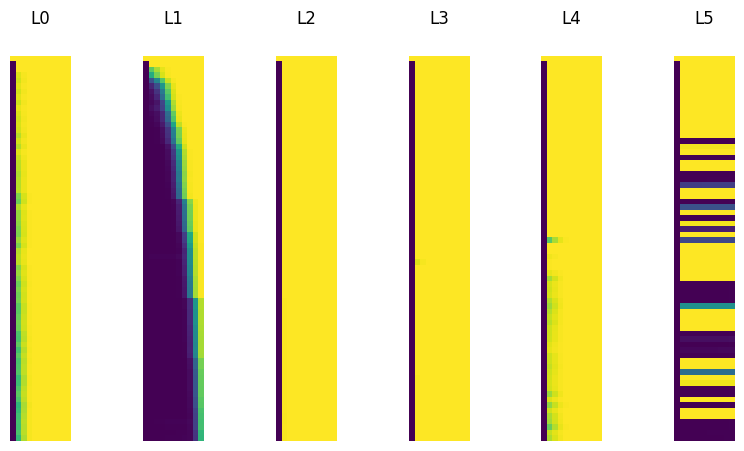

In [25]:
fig, axs = plt.subplots(1, 6, figsize=(10, 5))
for i in range(6):
	A = get_single_attn_pattern(1, i, 0)
	tt = resampled_tt(A, exact_l10=1, approx_l10=2.5, approx_pts=10)
	axs[i].matshow(tt[:, 0, :])
	axs[i].set_title(f"L{i}")
	axs[i].axis("off")

plt.show()

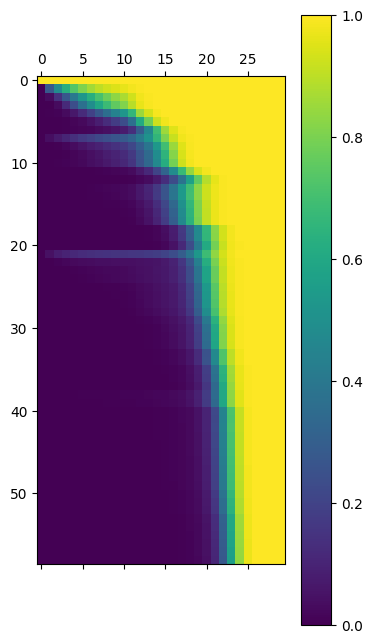

In [14]:
plt.matshow(T_resample[:, 0, :])
plt.colorbar()
plt.show()

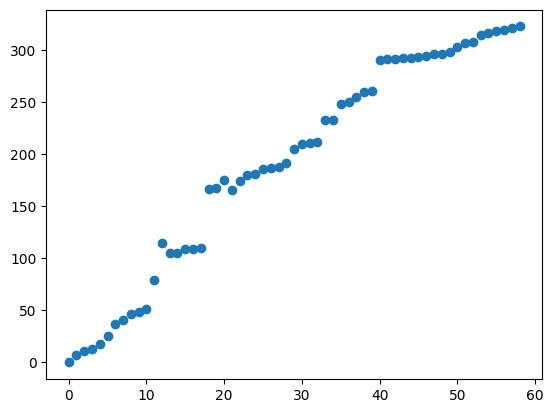

f:\projects\attention-motifs\.venv\Lib\site-packages\matplotlib\cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
f:\projects\attention-motifs\.venv\Lib\site-packages\matplotlib\cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


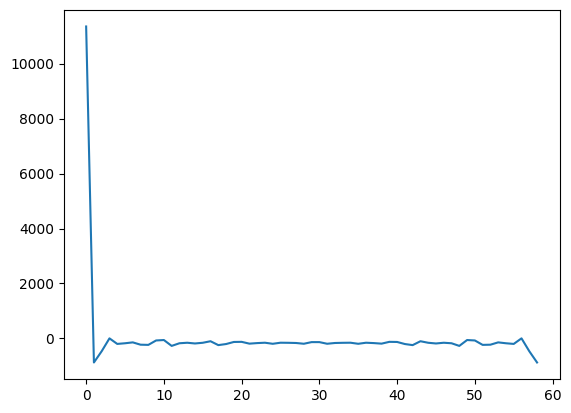

In [15]:
ttl = np.argmax(T[:, 0, :] > 0.9, axis=1)
ttl.shape
plt.plot(ttl, "o")
plt.show()

plt.plot(np.fft.fft(ttl))
plt.show()

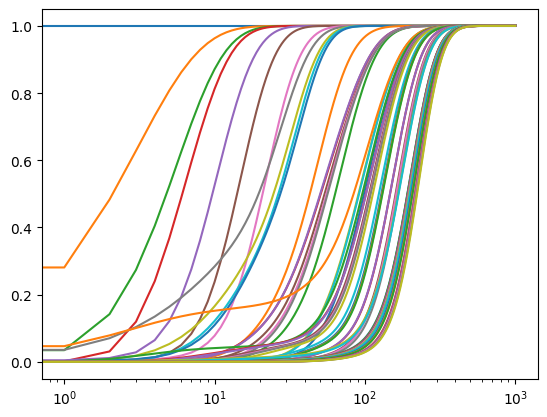

In [16]:
for i in range(n):
	plt.plot(T[i, 0, :], label=f"i={i}")
# plt.legend()
plt.xscale("log")
# plt.yscale("log")
plt.show()

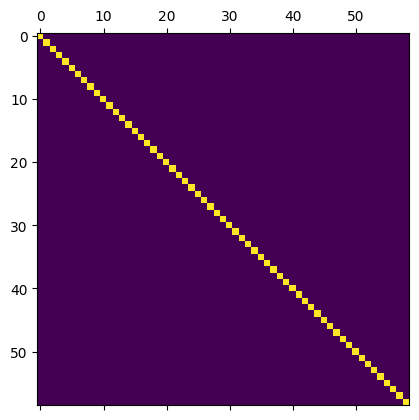

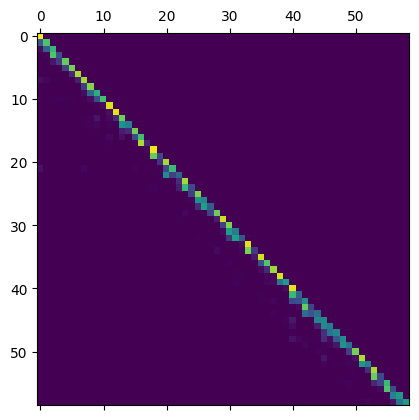

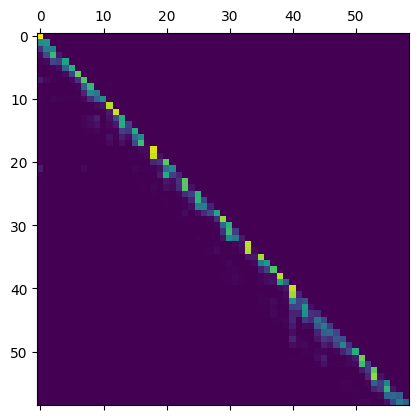

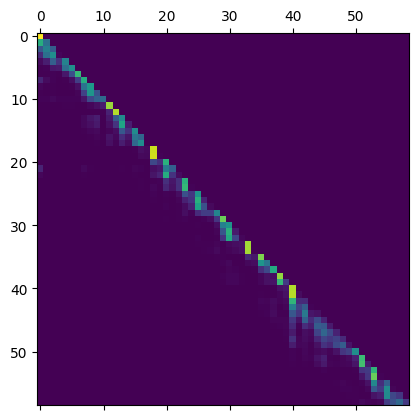

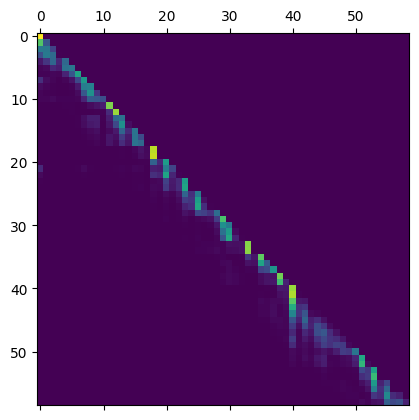

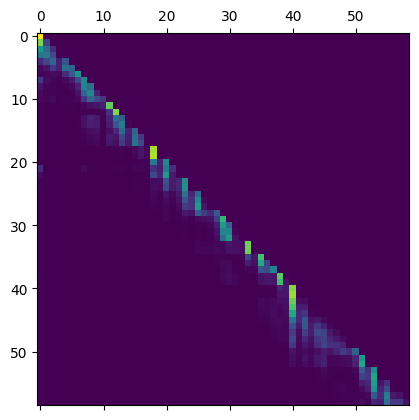

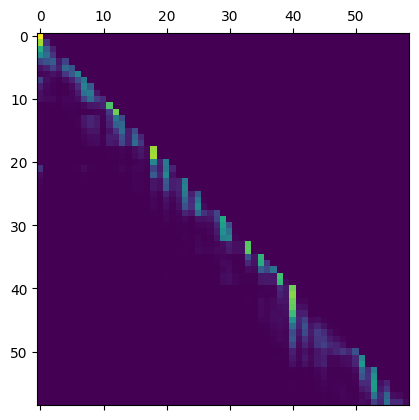

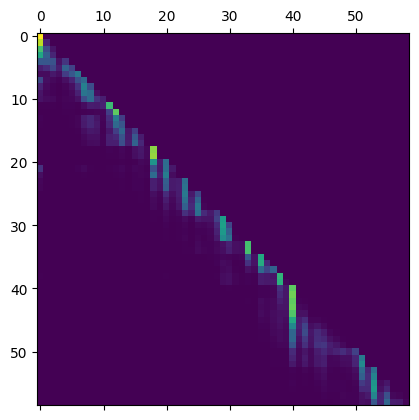

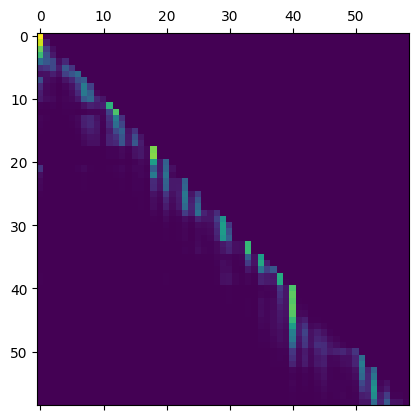

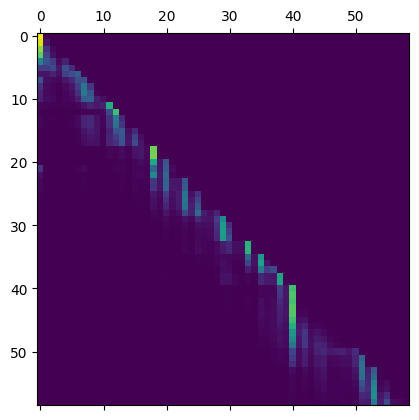

In [17]:
for i in range(10):
	plt.matshow(T[:, :, i])
	plt.show()